# Basic Image Enhancements with Mathematical Operations

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
from IPython.display import Image

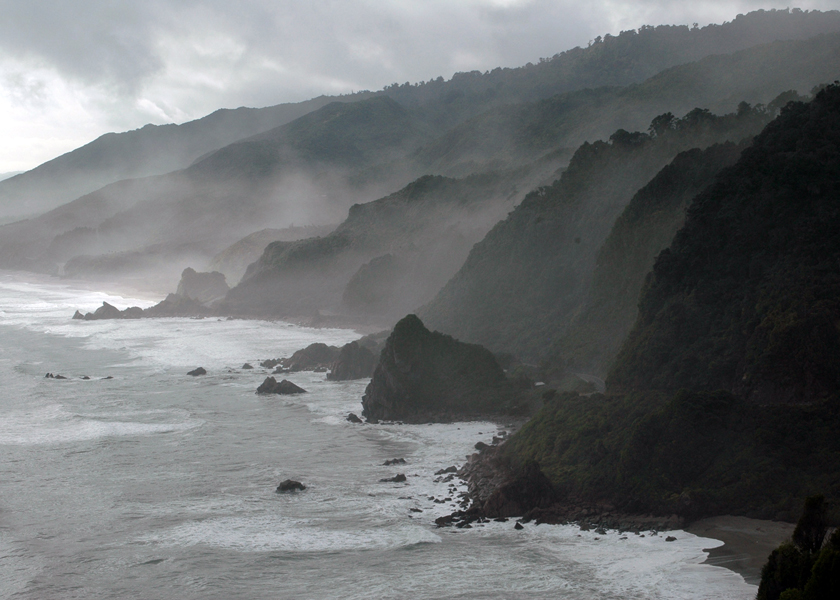

In [82]:
img_bgr = cv.imread("../Images/New_Zealand_Coast.jpg", cv.IMREAD_COLOR)
img = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

Image(filename="../Images/New_Zealand_Coast.jpg")

## Brightness (Addition)

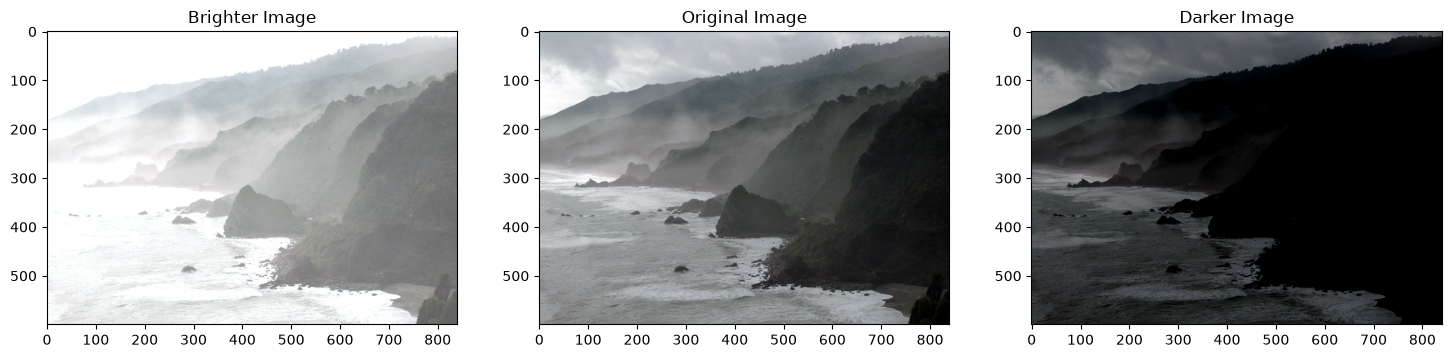

In [83]:
# Make the matrix/kernel for the operation. 
kernel = np.ones(img.shape, dtype = np.uint8) * 100

img_brighter = cv.add(img, kernel)
img_darker = cv.subtract(img, kernel)

plt.figure(figsize=(18, 5))
plt.subplot(131);plt.imshow(img_brighter);plt.title("Brighter Image")
plt.subplot(132);plt.imshow(img);plt.title("Original Image")
plt.subplot(133);plt.imshow(img_darker);plt.title("Darker Image")
plt.show()

## Contrast (Multiplication)

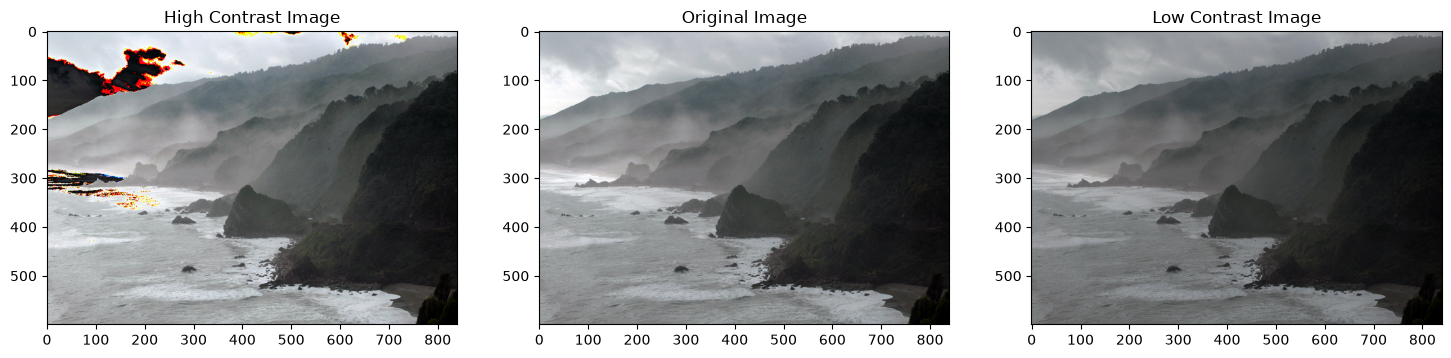

In [11]:
kernel_high = np.ones(img.shape, dtype = np.uint8) * 1.2
kernel_low = np.ones(img.shape, dtype = np.uint8) * 0.8

img_contrast_high = np.uint8(cv.multiply(np.float64(img), kernel_high))
img_contrast_low = np.uint8(cv.multiply(np.float64(img), kernel_low))

plt.figure(figsize=(18, 5))
plt.subplot(131);plt.imshow(img_contrast_high);plt.title("High Contrast Image")
plt.subplot(132);plt.imshow(img);plt.title("Original Image")
plt.subplot(133);plt.imshow(img_contrast_low);plt.title("Low Contrast Image")
plt.show()

The high contrast product now has some erroneous pixels where the values exceeded 255 and rolled over to the lower values. This can be remedied by np.clip().

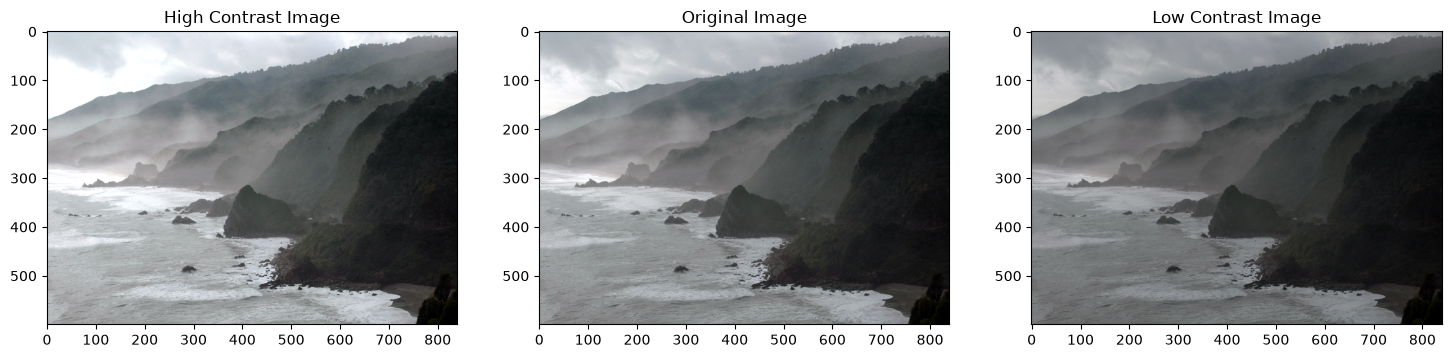

In [12]:
img_contrast_high = np.uint8(np.clip(cv.multiply(np.float64(img), kernel_high), 0, 255))

plt.figure(figsize=(18, 5))
plt.subplot(131);plt.imshow(img_contrast_high);plt.title("High Contrast Image")
plt.subplot(132);plt.imshow(img);plt.title("Original Image")
plt.subplot(133);plt.imshow(img_contrast_low);plt.title("Low Contrast Image")
plt.show()

## Image Thresholding

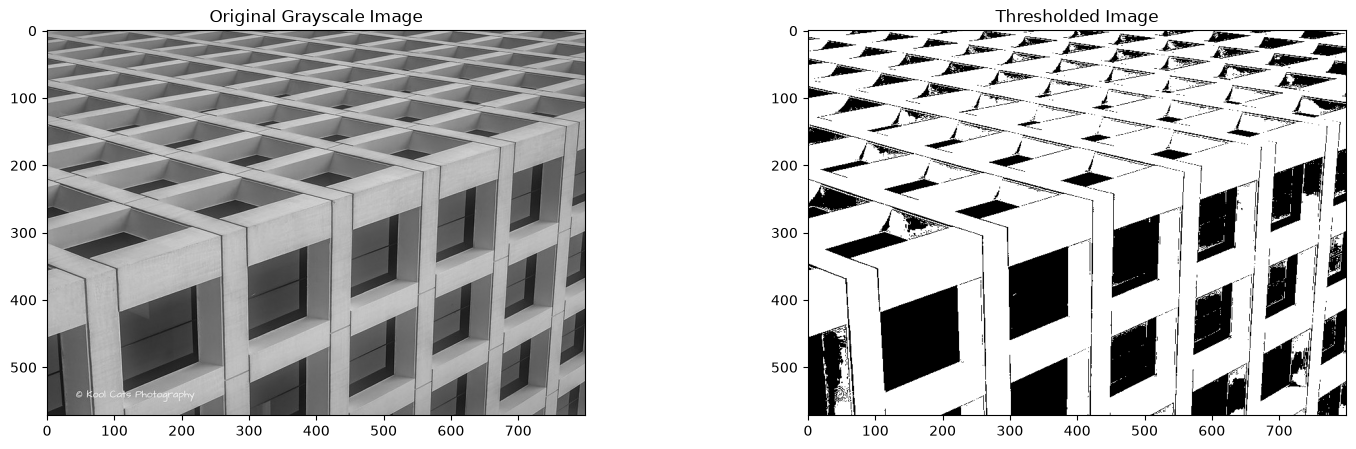

In [13]:
img_gray = cv.imread("../Images/building-windows.jpg", cv.IMREAD_GRAYSCALE)
retval, img_thresh = cv.threshold(img_gray, 100, 255, cv.THRESH_BINARY)

plt.figure(figsize=(18, 5))
plt.subplot(121);plt.imshow(img_gray, cmap = 'gray');plt.title("Original Grayscale Image")
plt.subplot(122);plt.imshow(img_thresh, cmap = 'gray');plt.title("Thresholded Image")
plt.show()

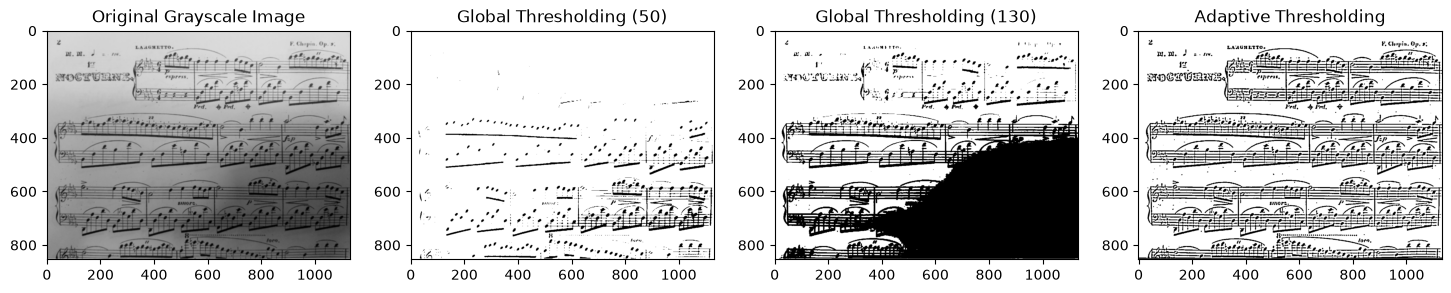

In [17]:
img = cv.imread("../Images/Piano_Sheet_Music.png", cv.IMREAD_GRAYSCALE)

retval, img_thresh_glb50 = cv.threshold(img, 50, 255, cv.THRESH_BINARY)

retval, img_thresh_glb130 = cv.threshold(img, 130, 255, cv.THRESH_BINARY)

img_thresh_adp = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 7)

plt.figure(figsize=(18, 5))

plt.subplot(141);plt.imshow(img, cmap = 'gray');plt.title("Original Grayscale Image")
plt.subplot(142);plt.imshow(img_thresh_glb50, cmap = 'gray');plt.title("Global Thresholding (50)")
plt.subplot(143);plt.imshow(img_thresh_glb130, cmap = 'gray');plt.title("Global Thresholding (130)")
plt.subplot(144);plt.imshow(img_thresh_adp, cmap = 'gray');plt.title("Adaptive Thresholding")   
plt.show()

I want o investigate what would happen if I were to increase contrast, and then global threshold.

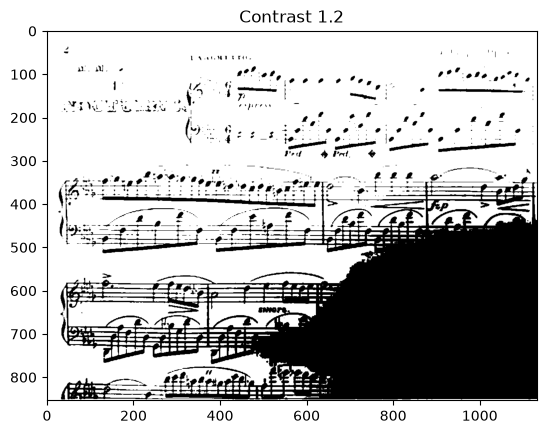

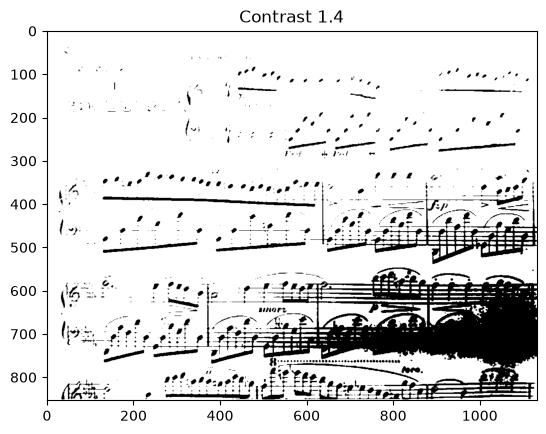

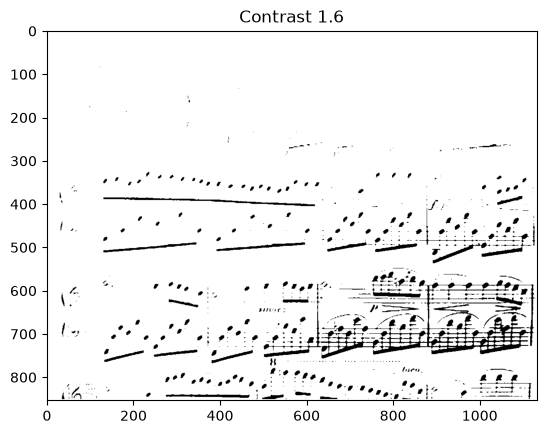

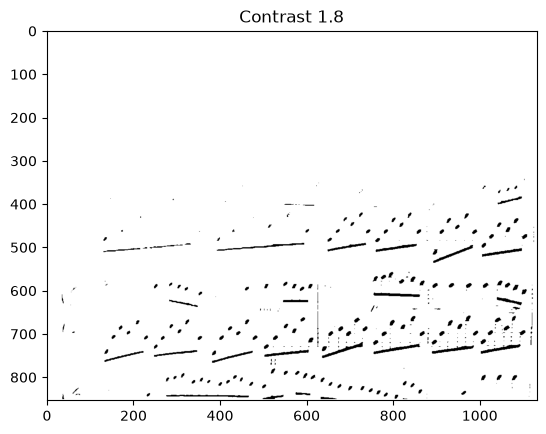

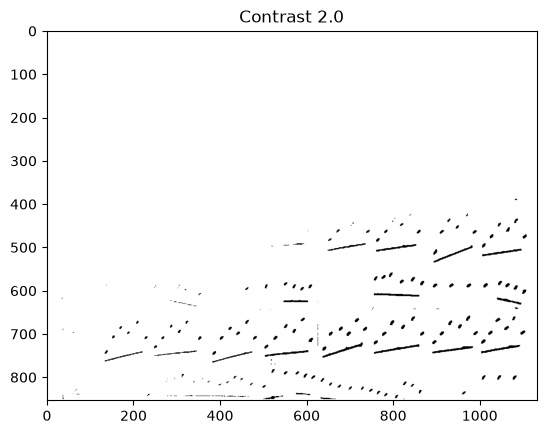

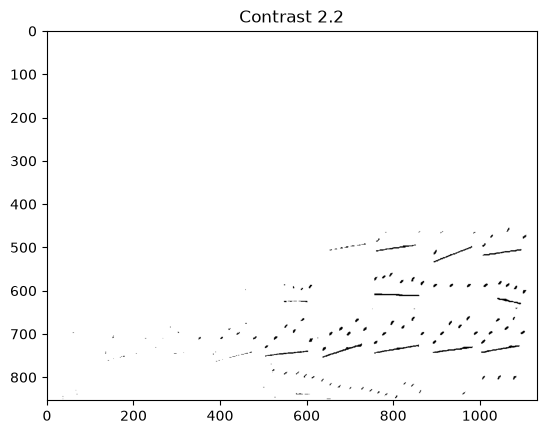

In [27]:
img_contrast_high = img.copy()

contrast_multiplier = np.array([1.2, 1.4, 1.6, 1.8, 2.0, 2.2])

for i, multiplier in enumerate(contrast_multiplier):
    contrast_kernel = np.ones(img_contrast_high.shape, dtype = np.uint8) * multiplier
    img_contrast_high = np.uint8(np.clip(np.float64(img_contrast_high) * contrast_kernel, 0, 255))
    retval, img_thresh_contrast_bgl = cv.threshold(img_contrast_high, 130, 255, cv.THRESH_BINARY)

    plt.figure()
    plt.imshow(img_thresh_contrast_bgl, cmap='gray')
    plt.title(f"Contrast {multiplier}")
    plt.show()
    

## Bitewise Operations

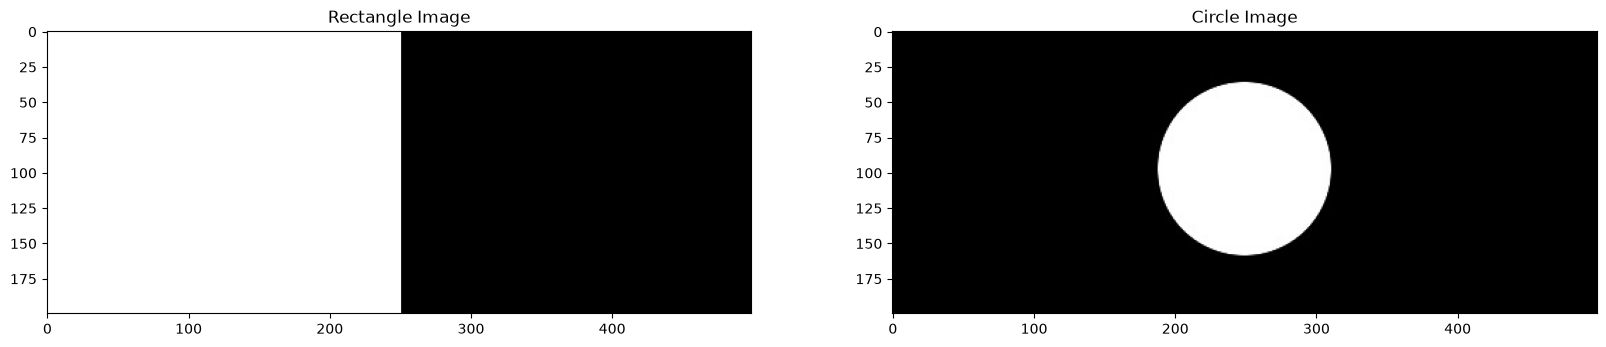

In [28]:
img_r = cv.imread("../Images/rectangle.jpg", cv.IMREAD_GRAYSCALE)
img_c = cv.imread("../Images/circle.jpg", cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(20, 5))
plt.subplot(121);plt.imshow(img_r, cmap = 'gray');plt.title("Rectangle Image")
plt.subplot(122);plt.imshow(img_c, cmap = 'gray');plt.title("Circle Image")
plt.show()  


### AND (Intersection )

Text(0.5, 1.0, 'Bitwise AND Operation')

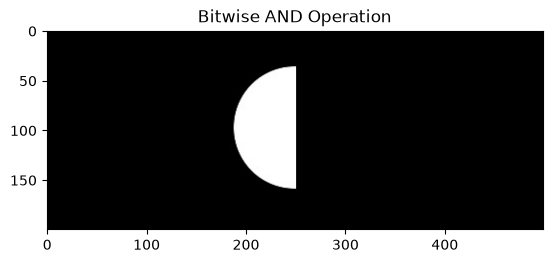

In [29]:
img_and = cv.bitwise_and(img_r, img_c, mask = None)
plt.imshow(img_and, cmap = 'gray');plt.title("Bitwise AND Operation")

### OR (Union)

Text(0.5, 1.0, 'Bitwise OR Operation')

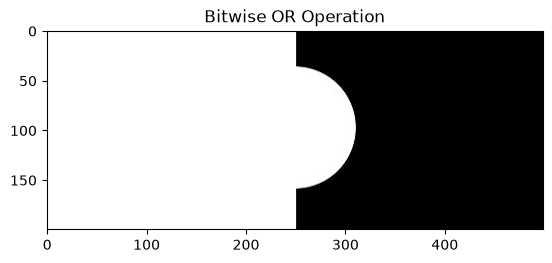

In [30]:
img_or = cv.bitwise_or(img_r, img_c, mask = None)
plt.imshow(img_or, cmap = 'gray');plt.title("Bitwise OR Operation")

### XOR (Difference)

Text(0.5, 1.0, 'Bitwise XOR Operation')

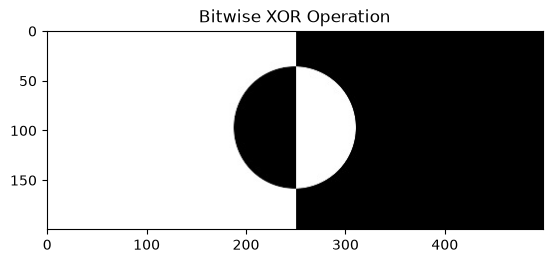

In [31]:
img_xor = cv.bitwise_xor(img_r, img_c, mask = None)
plt.imshow(img_xor, cmap = 'gray');plt.title("Bitwise XOR Operation")

### Applying Bitwise Operations

I was trying to be smart and see if I can do it without the answers. I got something similar, but peep the finished colors of the logo...

Text(0.5, 1.0, 'Result Image')

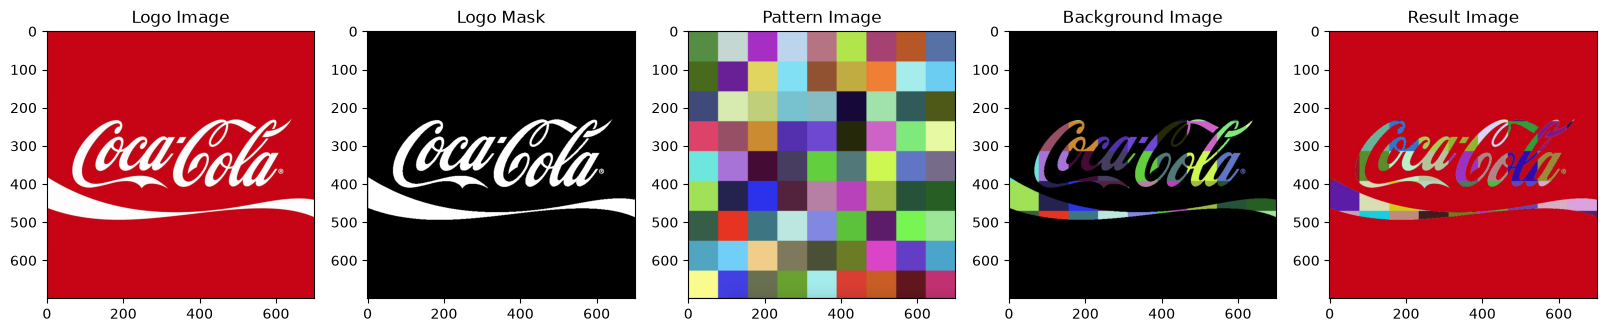

In [55]:
plt.figure(figsize=(20, 5))

img_logo_bgr = cv.imread("../Images/coca-cola-logo.png", cv.IMREAD_COLOR)
img_logo = cv.cvtColor(img_logo_bgr, cv.COLOR_BGR2RGB)

plt.subplot(1, 5, 1)
plt.imshow(img_logo)
plt.title("Logo Image")

img_logo_gray = cv.cvtColor(img_logo_bgr, cv.COLOR_BGR2GRAY)
retval, logo_mask = cv.threshold(img_logo_gray, 127, 255, cv.THRESH_BINARY)

plt.subplot(1, 5, 2)
plt.imshow(logo_mask, cmap = 'gray')
plt.title("Logo Mask")

img_logo_w = img_logo.shape[0]
img_logo_h = img_logo.shape[1]
aspect_ratio = img_logo_w / img_logo_h

img_pattern_bgr = cv.imread("../Images/checkerboard_color.png", cv.IMREAD_COLOR)
img_pattern = cv.cvtColor(img_pattern_bgr, cv.COLOR_BGR2RGB)

img_pattern_resized = cv.resize(img_pattern, (img_logo_h, img_logo_w), interpolation = cv.INTER_AREA)

plt.subplot(1, 5, 3)
plt.imshow(img_pattern_resized)
plt.title("Pattern Image")


background = cv.bitwise_and(img_pattern_resized, img_pattern_resized, mask = logo_mask)

plt.subplot(1, 5, 4)
plt.imshow(background)
plt.title("Background Image")

result_logo = cv.bitwise_xor(img_logo, background)

plt.subplot(1, 5, 5)
plt.imshow(result_logo)
plt.title("Result Image")

Actual answer now:

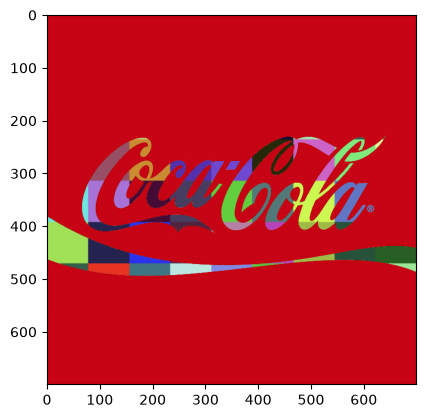

In [80]:
# Getting foreground
logo_bgr = cv.imread("../Images/coca-cola-logo.png", 1)
logo = cv.cvtColor(logo_bgr, cv.COLOR_BGR2RGB)
logo_gray = cv.cvtColor(logo_bgr, cv.COLOR_BGR2GRAY)
logo_gray = cv.threshold(logo_gray, 127, 255, cv.THRESH_BINARY)[1]
inv_logo_gray = cv.bitwise_not(logo_gray)
inv_logo_gray = cv.threshold(inv_logo_gray, 127, 255, cv.THRESH_BINARY)[1]

foreground = cv.bitwise_and(logo, logo, mask = inv_logo_gray)

# Getting background
pattern_bgr = cv.imread("../Images/checkerboard_color.png", 1)
pattern = cv.cvtColor(pattern_bgr, cv.COLOR_BGR2RGB)
pattern = cv.resize(pattern, (logo.shape[1], logo.shape[0]), interpolation = cv.INTER_AREA)

background = cv.bitwise_and(pattern, pattern, mask = logo_gray)

# Combine
result = cv.bitwise_or(foreground, background)

plt.imshow(result)

